In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Phương pháp PCA

* PCA là phương pháp đi tìm 1 hệ cơ sở mới sao cho thông tin chủ yếu tập trung ở 1 vài tọa độ, phần còn lại chỉ mang 1 lượng nhỏ thông tin. Để đơn giản tính toán, PCA sẽ tìm 1 **hệ trực chuẩn** làm cơ sở mới
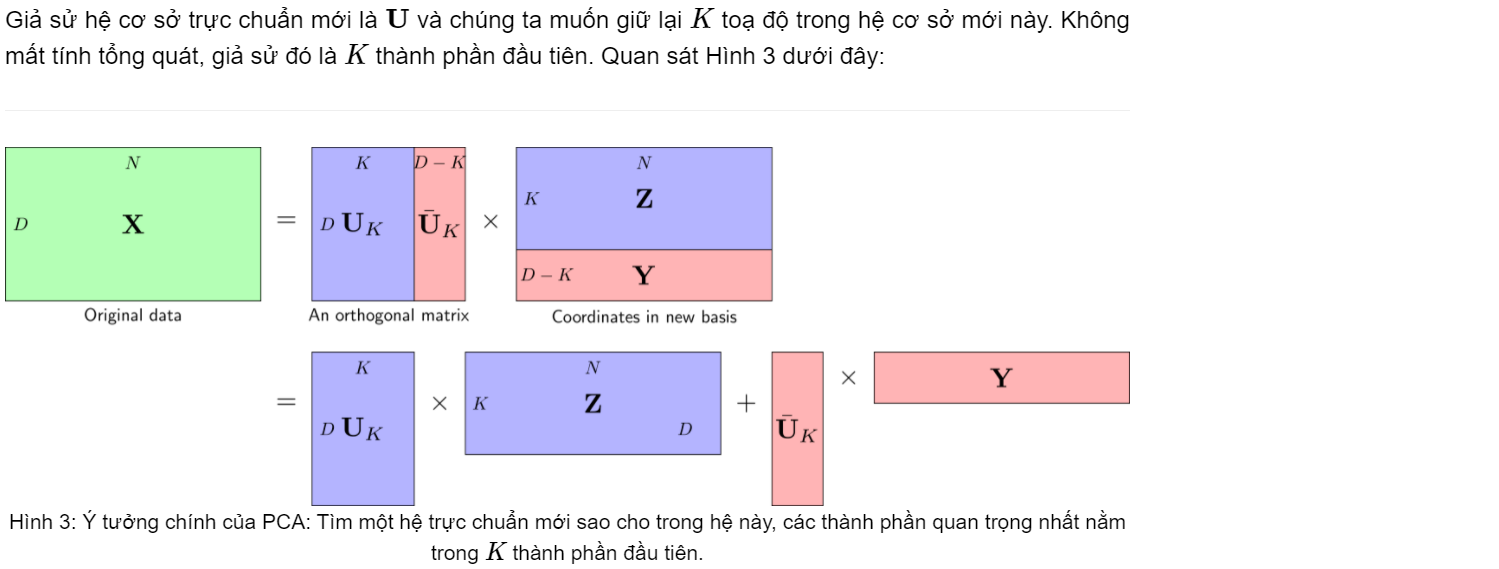
* Nhìn hình trên, ta thấy mục đích PCA là tìm ma trận trực giao $\normalsize{\textbf{U}}$ sao cho phần lớn thông tin đc giữ lại ở ma trận $\normalsize{\textbf{U}_K}$ và $\normalsize{\textbf{Z}}$ còn phần màu đỏ ở ma trận $\normalsize{\mathbf{\bar U}_K}$ và $\normalsize{\textbf{Y}}$ sẽ được loại bỏ. Thay thế bằng 1 ma trận ko phụ thuộc vào điểm dữ liệu
* Khi ta xấp xỉ ma trận $\normalsize{\textbf{Y}}$ bằng các vector cột $\normalsize{\textbf{b}}$, lúc này $\normalsize{\mathbf{Y \approx b \cdot 1}^{T}}$. Sau khi tính toán được $\normalsize{\mathbf{b}}$ làm cho mất mát nhỏ nhất, ta thay vào ma trận $\normalsize{\mathbf{X}}$ ban đầu được:
> $\large{\mathbf{X \approx \tilde X = U}_{K}\mathbf{Z + \bar U}_{K}\mathbf{\bar U}_{K}^{T}\mathbf{\bar x}\mathbf{1}^{T}}$
* Để tìm hàm mất mát, ta mong muốn sự sai khác giữa $\normalsize{\textbf{X}}$ và $\normalsize{\mathbf{\tilde X}}$ là nhỏ nhất, từ công thức của $\normalsize{\mathbf{X}}$ và $\normalsize{\mathbf{\tilde X}}$ ta có hàm mất mát:
> $\large{\mathbf{J} = \frac{1}{N}||\mathbf{X - \tilde X}||_{F}^{2} = \frac{1}{N}||\mathbf{\bar U}_{K}\mathbf{\bar U}_{K}^{T}\mathbf{X} - \mathbf{\bar U}_{K}\mathbf{\bar U}_{K}^{T}\mathbf{\bar x}\mathbf{1}^{T}}||_{F}^{2}$
* Sau 1 vài biến đổi, ta đưa hàm mất mát về dạng:
> $\large{\mathbf{J} = \sum_{i = K + 1}^{D}\mathbf{u}_{i}^{T}\mathbf{Su}_{i}}$ với $\Large{\mathbf{S}}$ là ma trận hiệp phương sai của dữ liệu
* Nếu ta thay $\normalsize{K = 0}$ vào công thức trên ta có hàm sau (với $\normalsize{\lambda_{i}}$ là các trị riêng của ma trận $\normalsize{\mathbf{S}}$):
> $\large{\mathbf{L} = \sum_{i = 1}^{D}\mathbf{u}_{i}^{T}\mathbf{Su}_{i} = \frac{1}{N}||\hat{\mathbf{X}}^T\mathbf{U}||_{F}^{2} = \frac{1}{N}trace(\hat{\mathbf{X}}^T\mathbf{U} \mathbf{U}^T \hat{\mathbf{X}}) = trace(\mathbf{S}) = \sum_{i=1}^{D}\lambda_i}$ 
* Sau đó để tối thiểu $\normalsize{\mathbf{J}}$ sẽ tương đương vs việc tối đa hàm sau:
> $\large{\mathbf{F = L - J = }\sum_{i = 1}^{K}\mathbf{u}_{i}\mathbf{S}\mathbf{u}_{i}^{T}}$
* $\normalsize{\mathbf{F}}$ sẽ đạt gtri lớn nhất bằng $\normalsize{\sum_{i = 1}^{K}\lambda_{i}}$ khi $\normalsize{\mathbf{u}_{i}}$ là các vector riêng có norm 2 bằng 1 ứng vs các trị riêng này (nhớ điều kiện trực giao giữa các $\normalsize{\mathbf{u}_{i}}$)

# 2. Các bước thực hiện PCA

1. Tính vector kỳ vọng của toàn bộ dữ liệu:
> $\large{\mathbf{\bar x} = \frac{1}{N}\sum_{n = 1}^{N}\textbf{x}_{n}}$
2. Trừ mỗi điểm dữ liệu đi vector kỳ vọng của toàn bộ dữ liệu:
> $\large{\mathbf{\hat x}_{n} = \mathbf{x}_{n} - \mathbf{\bar x}}$
3. Tính ma trận hiệp phương sai:
> $\large{\mathbf{S} = \frac{1}{N}\mathbf{\hat X \hat X}^{T}}$
4. Tính các trị riêng và vector riêng có norm bằng 1 của ma trận này, sắp xếp chúng theo thứ tự giảm dần của trị riêng
5. Chọn $\normalsize{\mathbf{K}}$ vector riêng ứng vs $\normalsize{\mathbf{K}}$ trị riêng lớn nhất để xây dựng ma trận $\normalsize{\mathbf{U}_{K}}$ có các cột tạo thành 1 hệ trực giao. $\normalsize{\mathbf{K}}$ vectors này còn đc gọi là các thành phần chính (principal components) tạo thành 1 ko gian con *gần* vs phân bố của dữ liệu ban đầu đã chuẩn hóa
6. Chiếu dữ liệu ban đầu đã chuẩn hóa $\normalsize{\mathbf{\hat X}}$ xuống ko gian con tìm đc
7. Dữ liệu ms chính là tọa độ của các điểm dữ liệu trên ko gian ms
> $\large{\mathbf{Z} = \mathbf{U}_{K}^{T}\mathbf{\hat X}}$
8. Dữ liệu ban đầu có thể tính đc xấp xỉ dữ liệu ms như sau:
> $\large{\mathbf{x}\approx\mathbf{U}_{K}\mathbf{Z} + \mathbf{\bar x}}$

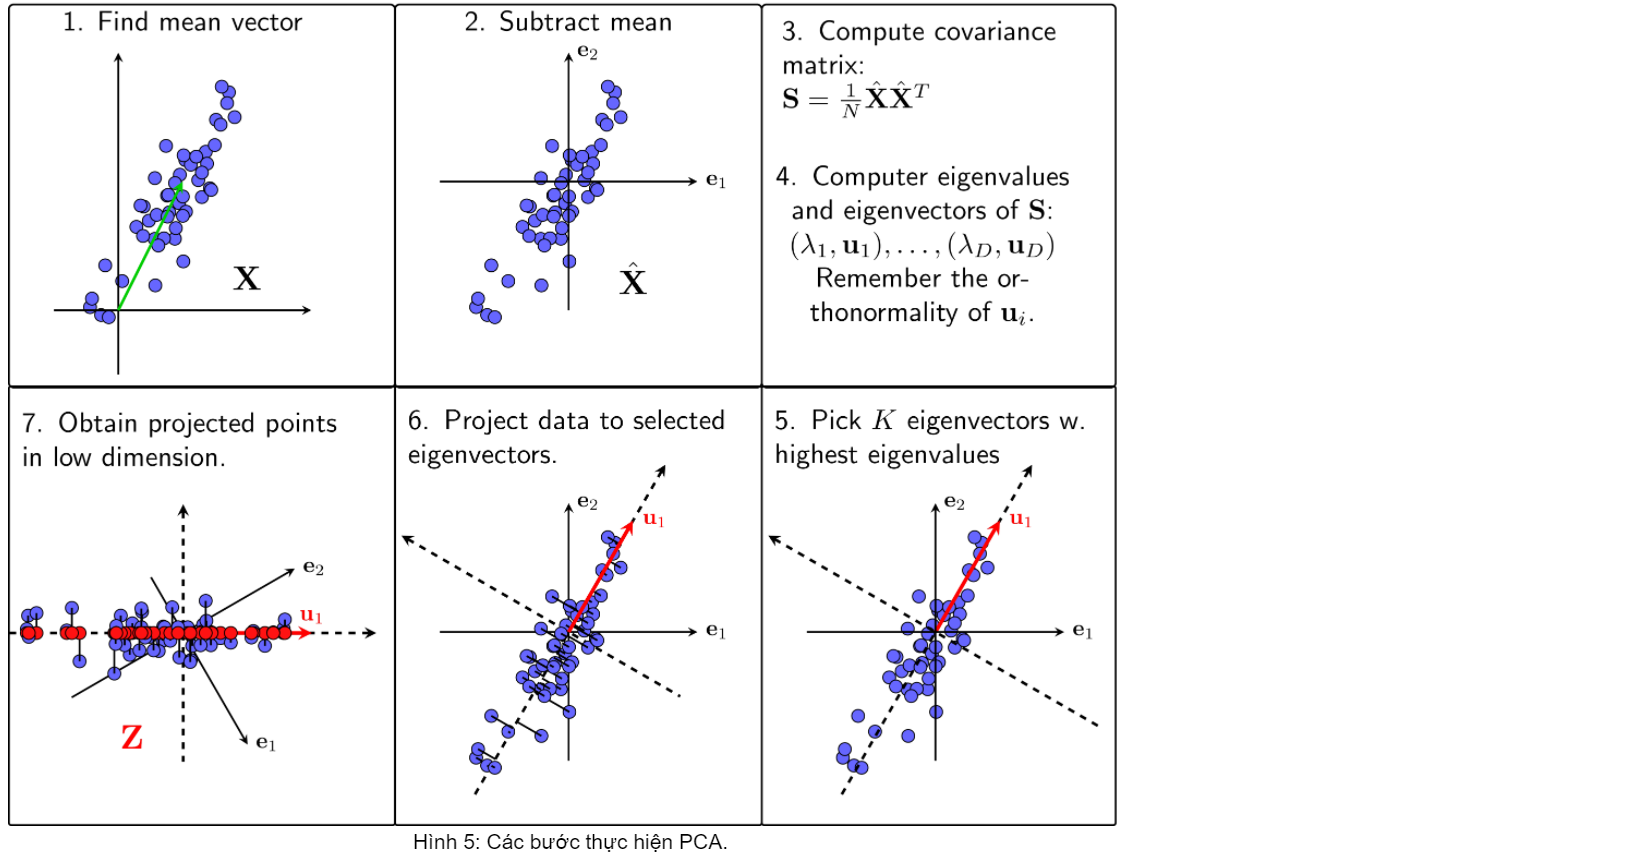

# 3. Mối quan hệ SVD và PCA

### a. Nhắc lại về SVD:
* Nghiệm $\normalsize{\textbf{A}}$ của bài toán xấp xỉ 1 ma trận bởi 1 ma trận khác có rank ko vượt quá $k$:
> $\large{\text{min}_{A}||\textbf{X - A}||_{F}}$ subject to: $\large{\text{rank(}\mathbf{A}\text{) = }\mathbf{K}}$
* Truncated SVD của $\normalsize{\mathbf{A}}$ như sau:
> $\large{\mathbf{A} = \mathbf{U}_{K}\mathbf{\Sigma}_{K}\mathbf{V}_{K}^{T}}$
### b. Nhắc lại về PCA:
* Ở công thức đã chứng minh:
> $\large{\mathbf{X \approx \tilde X = U}_{K}\mathbf{Z + \bar U}_{K}\mathbf{\bar U}_{K}^{T}\mathbf{\bar x}\mathbf{1}^{T}}$
* Ta giả sử vector kỳ vọng $\normalsize{\bar x} = 0$. Ta sẽ có:
> $\large{\mathbf{X \approx \tilde X = U}_{K}\mathbf{Z}}$
* Lúc này bài toán tối ưu PCA trở thành:
> $\large{\mathbf{U}_K, \mathbf{Z} = \min_{\mathbf{U}_K, \mathbf{Z} } ||\mathbf{X} - \mathbf{U}_K \mathbf{Z}||_F}$ subject to:  $\large{\mathbf{U}_K^T \mathbf{U}_K = \mathbf{I}_K}$
### c. Quan hệ SVD và PCA:
* Nhìn vào 2 công thức phải tối ưu $\normalsize{min}$ ở SVD và PCA, ta thấy điểm tương đồng là biểu thức trong dấu $\normalsize{min}$ đều xuất hiện vế $"\normalsize{\mathbf{X -}}"$, sau đó ma trận $\normalsize{\textbf{A}}$ ở SVD được biến đổi thành $\normalsize{\mathbf{U}_{K}}$ và $\normalsize{\mathbf{Z}}$ ở PCA. Lúc này ta có thể thấy:
    > $\large{\mathbf{U}_{k}}$ ở PCA bằng $\large{\mathbf{U}_{k}}$ ở SVD
    
    > $\large{\mathbf{Z}}$ ở PCA bằng $\large{\mathbf{\Sigma}_{K}\mathbf{V}_{K}^{T}}$ ở SVD

# 4. Cách để chọn chiều của dữ liệu mới

* Ta coi biểu thức sau là lượng thông tin được giữ lại khi số chiều mới sau PCA là $\normalsize{K}$
> $\Large{r_{K} = \frac{\sum_{i = 1}^{K}\lambda_{i}}{\sum_{j = 1}^{D}\lambda_{j}}}$
* Ví dụ nếu muốn giữ lại 99% dữ liệu, ta chỉ cần chọn $\normalsize{K}$ là số tự nhiên nhỏ nhất sao cho:
> $\large{r_{K} \geq 0.99}$

# 5. Lưu ý về PCA
*Ở phần này ta sẽ coi dữ liệu đã được chuẩn hóa (đã trừ đi vector kỳ vọng), tức viết là $\normalsize{\mathbf{X}}$ thay vì $\normalsize{\mathbf{\hat X}}$ và ma trận hiệp phương sai $\normalsize{\mathbf{S} = \frac{1}{N}\mathbf{XX}^{T}}$*

**a. Khi số chiều dữ liệu nhiều hơn số điểm dữ liệu ($\normalsize{D > N}$)**
* Khi này, trị riêng khác 0 của ma trận hiệp phương sai $\normalsize{\mathbf{S}}$ sẽ ko vượt quá rank của nó (ko vượt quá $\normalsize{N}$). Lúc đó, ta buộc phải chọn $\normalsize{K \leq N}$
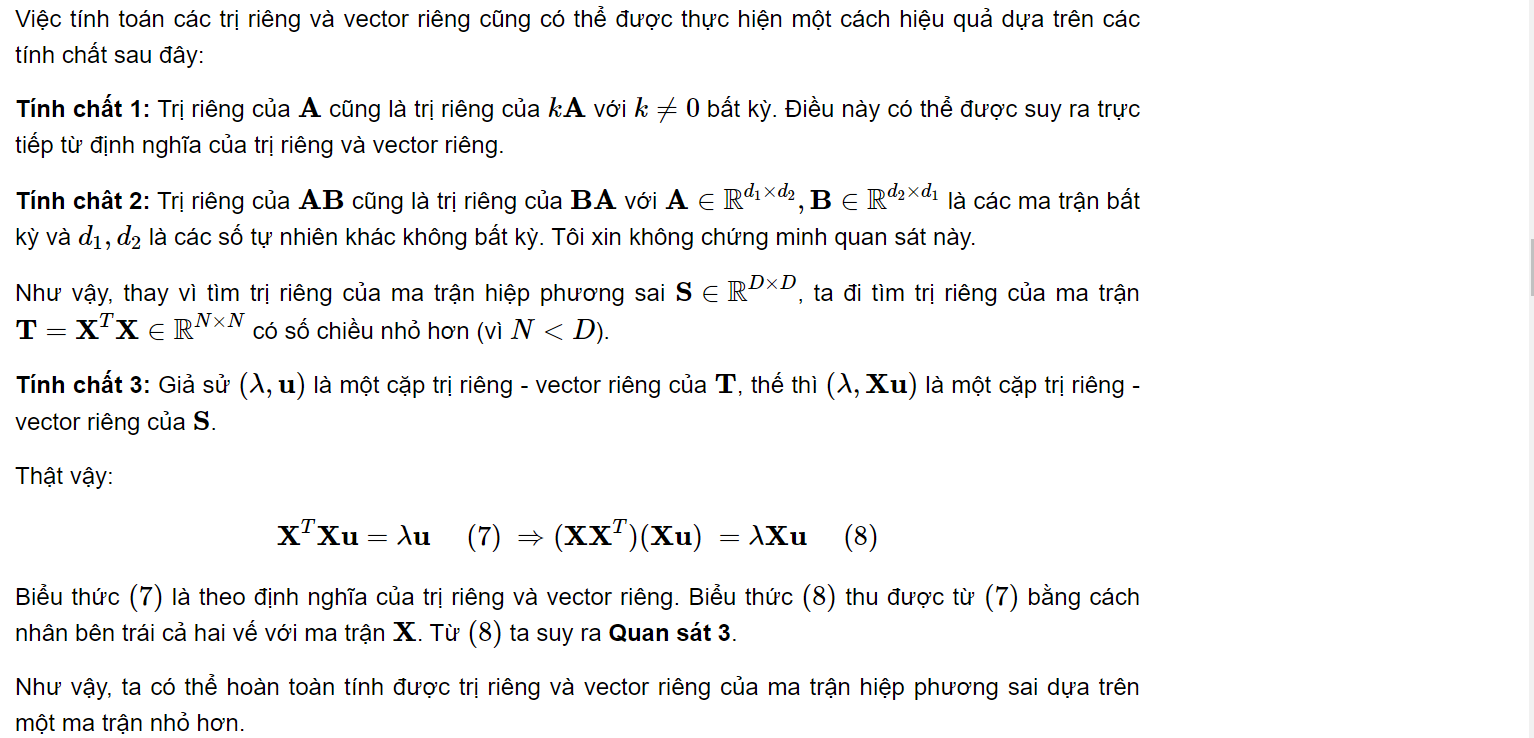

**b. Với các bài toán large-scale**
* Khi cả $\normalsize{D}$ và $\normalsize{N}$ đều là những số rất lớn, việc tính trực tiếp trị riêng và vector riêng cho ma trận hiệp phương sai là ko khả thi. Ta có thể tính xấp xỉ các gtri này vs phương pháp tên là **Power Method**:
    > Phương pháp **Power** tìm trị riêng và vector riêng của 1 ma trận nửa xác định dương $\normalsize{\mathbf{A} \in \mathbf{R}^{nxn}}$:
    > 1. Chọn 1 vector $\normalsize{\mathbf{q}^{(0)} \in \mathbf{R}^{n}}$ *với* $\normalsize{||\mathbf{q}^{(0)}||_{2} = 1}$ bất kỳ
    > 2. Với $\normalsize{k = 1, 2, ...}$ ta tính $\normalsize{\mathbf{z} = \mathbf{Aq}^{(k-1)}}$
    > 3. Chuẩn hóa: $\normalsize{\mathbf{q}^{(k)} = \mathbf{z}/||\mathbf{z}||_{2}}$
    > 4. Nếu $\normalsize{||\mathbf{q}^{(k)} - \mathbf{q}^{(k - 1)}||_{2}}$ đủ nhỏ thì dừng lại. Nếu ko thì $\normalsize{k := k + 1}$ rồi quay lại bước 2
    > 5. $\normalsize{\mathbf{q}^{(k)}}$ chính là vector riêng ứng vs trị riêng lớn nhất $\normalsize{\lambda_{1} = (\mathbf{q}^{(k)})^{T}\mathbf{Aq}^{(k)}}$
    
* Dựa vào phương pháp **Power** trên, ta rút ra **định lý**:
    > Nếu ma trận nửa xác định dương $\normalsize{\mathbf{A}}$ có các trị riêng $\normalsize{\lambda_{1} \geq \lambda_{2} \geq \cdots \geq \lambda_{n} (\geq 0)}$ và các vector riêng tương ứng $\normalsize{\mathbf{v}_{1}, \mathbf{v}_{2}, \cdots, \mathbf{v}_{n}}$. Hơn nữa, các vectors riêng này tạo thành 1 hệ trực chuẩn, thì ma trận $\large{\mathbf{B} = \mathbf{A} - \lambda_{1}\mathbf{v}_{1}\mathbf{v}_{1}^{T}}$ có các trị riêng $\normalsize{\lambda_{2} \geq \lambda_{3} \geq \cdots \geq \lambda_{n} \geq 0}$ và các vector riêng tương ứng là $\normalsize{\mathbf{v}_{2}, \mathbf{v}_{3} \cdots, \mathbf{v}_{n}}$

* Sau đó cặp $\normalsize{(\lambda_{2}, \mathbf{v}_{2})}$ là cặp trị riêng - vector riêng lớn nhất của ma trận $\normalsize{\mathbf{B}}$. Sau đó ta lại tiếp tục thực hiện **Power Method** để tìm cặp biến số này cho đến khi ta xấp xỉ đc tất cả trị riêng - vector riêng tương ứng của ma trận hiệp phương sai (lưu ý chỉ tìm tới trị riêng thứ $\normalsize{K}$ của ma trận hiệp phương sai)

# 6. Ví dụ với Python

### Eigenface

In [41]:
path = 'YALE\\unpadded\\'
ids = range(1, 16)
states = ['centerlight', 'glasses', 'happy', 'leftlight',
          'noglasses', 'normal', 'rightlight','sad',
          'sleepy', 'surprised', 'wink']
prefix = 'subject'
surfix = '.pgm'

h = 116
w = 98
D = h * w
N = len(states) * 15
K = 100

In [42]:
X = np.zeros((D, N))
cnt = 0

for person_id in range(1, 16):
    for state in states:
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        X[:, cnt] = plt.imread(fn).reshape(D)
        cnt += 1

In [43]:
from sklearn.decomposition import PCA
np.random.seed(37)

pca = PCA(n_components = K)
pca.fit(X.T)

U = pca.components_.T

In [46]:
print(U.shape)

(11368, 100)


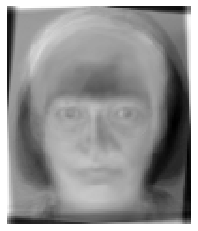

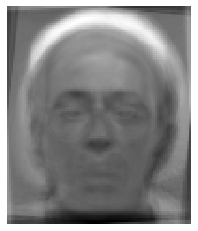

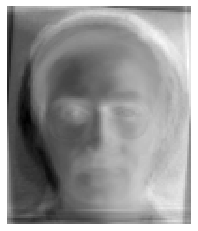

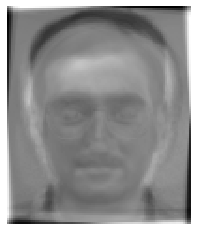

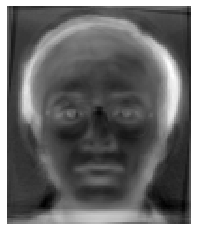

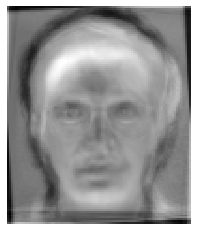

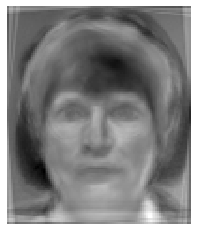

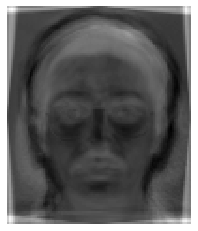

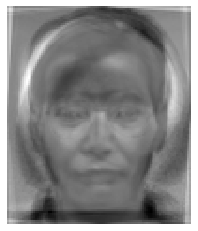

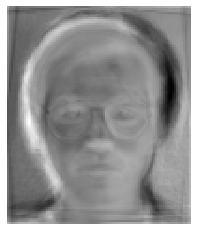

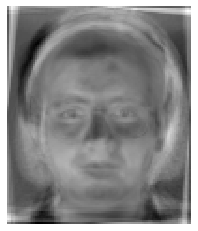

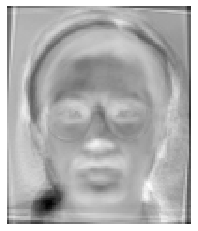

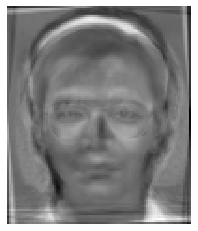

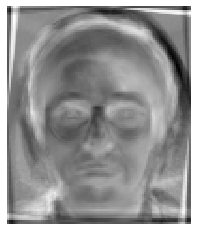

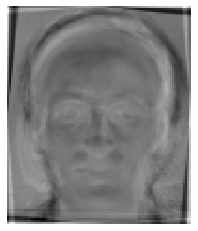

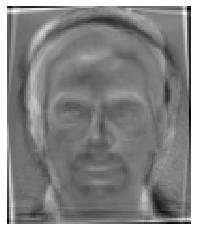

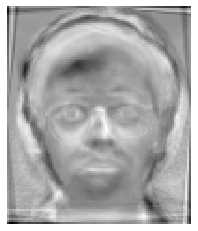

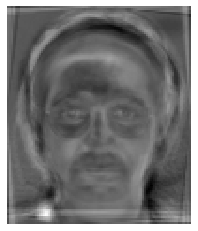

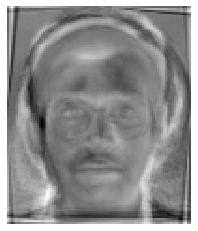

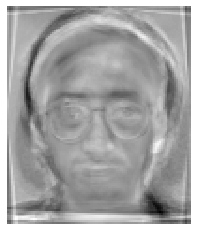

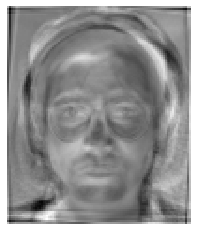

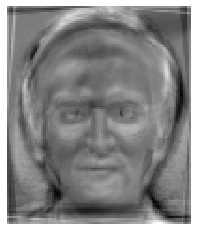

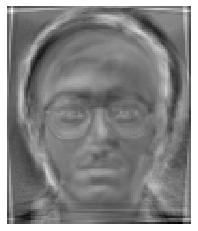

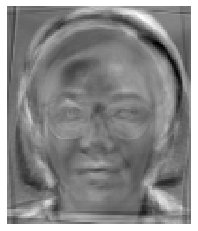

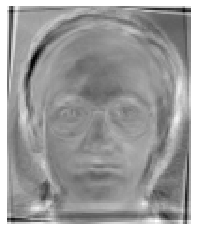

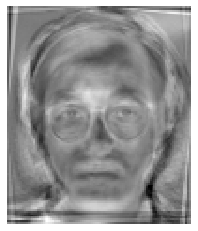

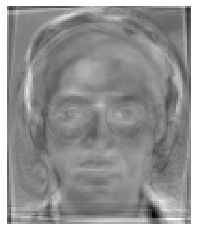

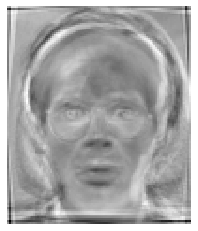

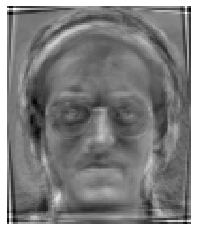

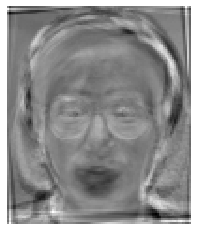

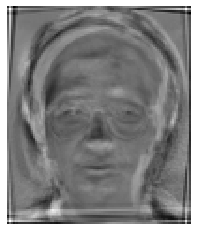

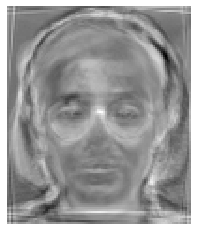

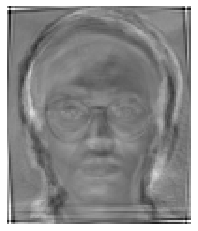

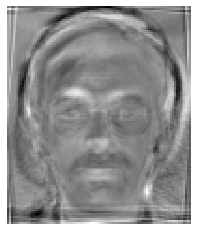

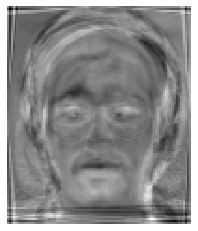

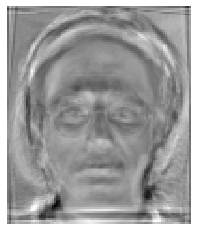

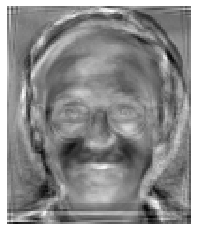

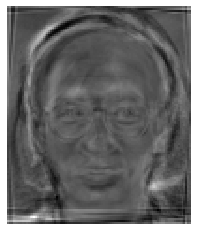

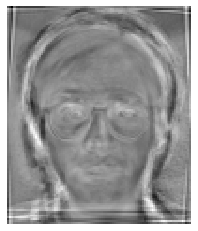

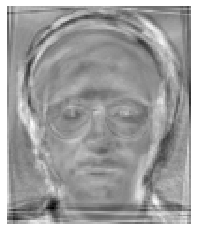

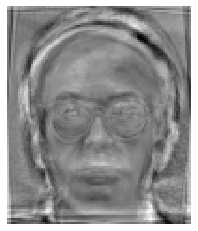

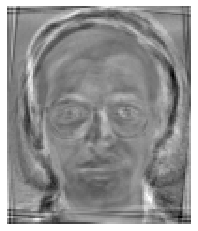

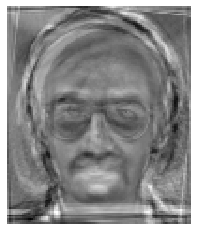

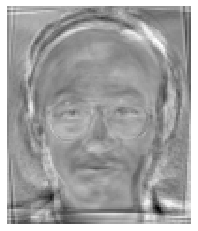

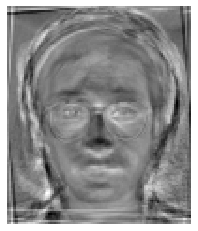

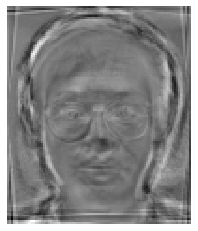

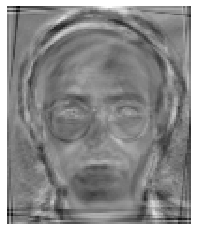

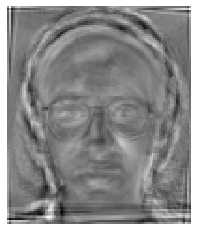

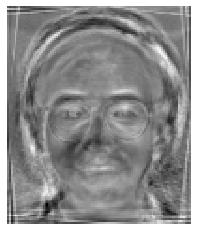

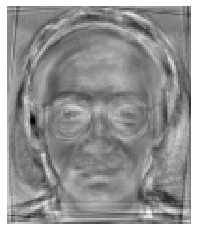

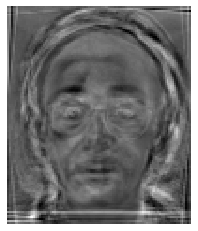

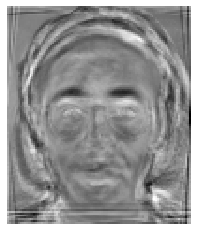

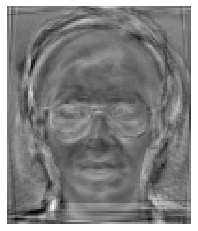

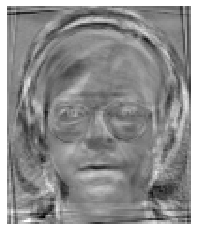

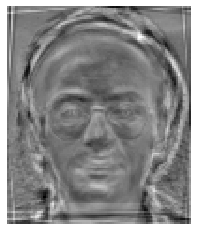

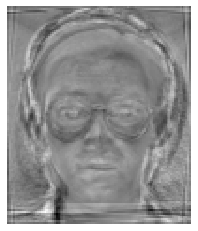

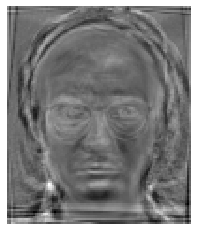

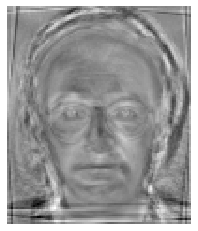

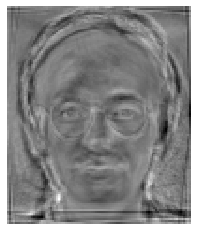

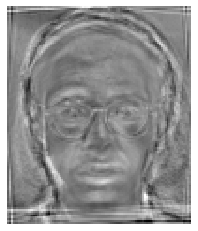

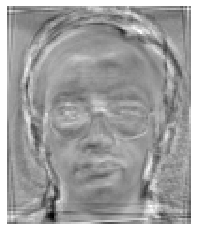

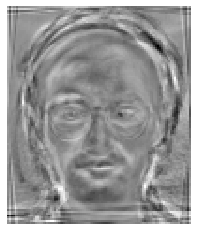

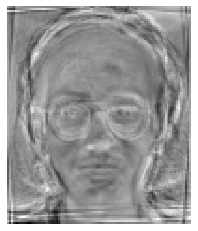

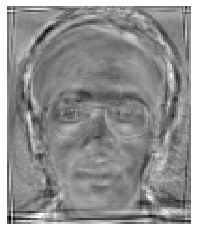

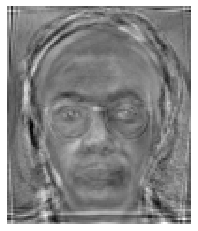

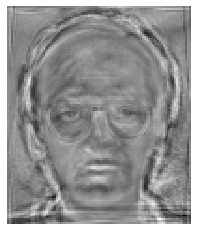

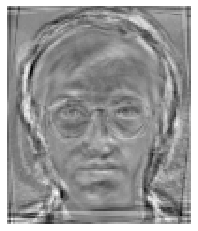

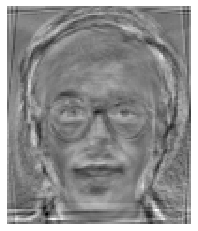

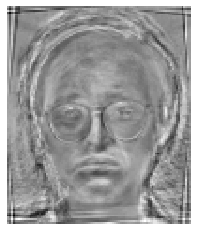

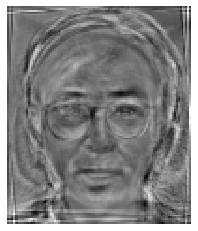

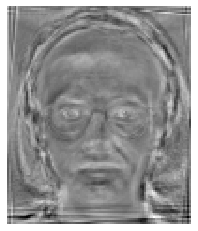

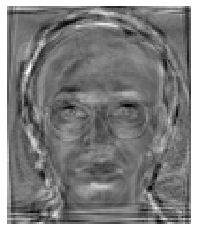

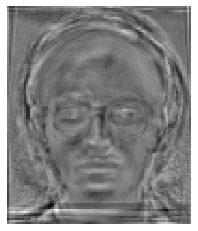

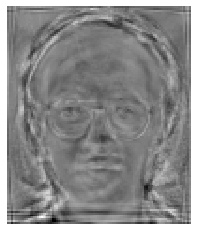

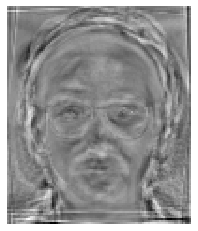

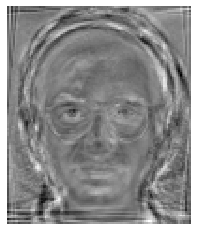

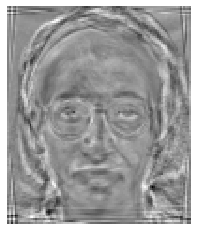

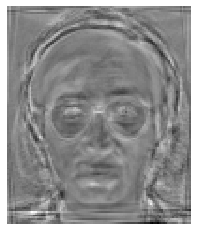

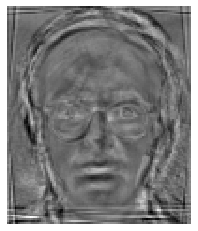

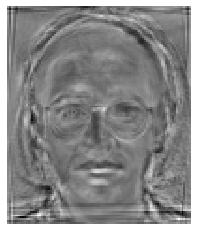

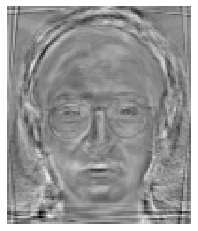

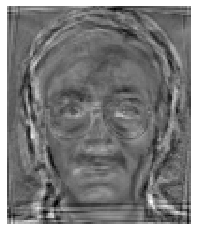

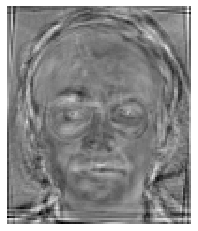

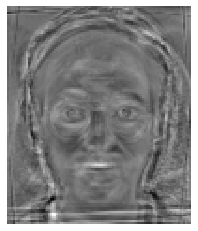

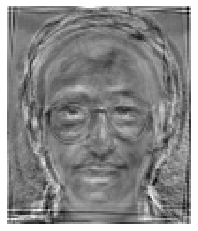

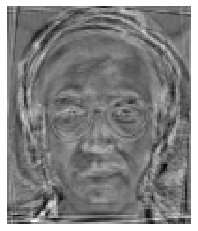

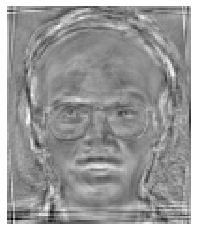

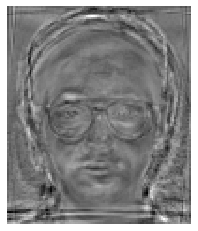

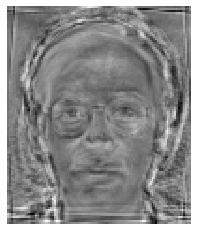

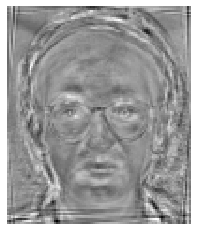

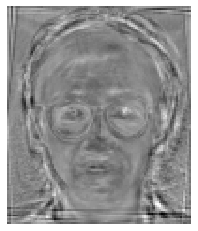

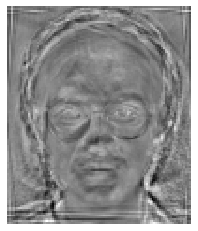

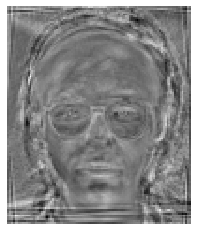

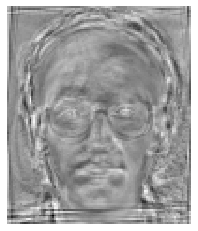

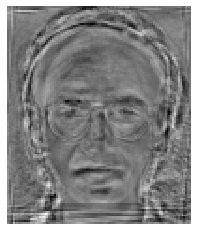

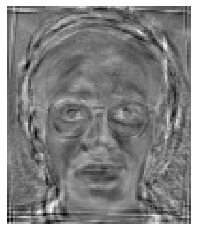

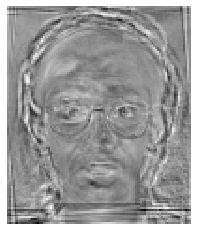

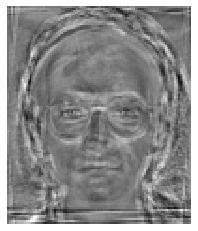

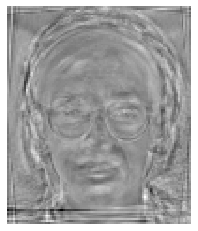

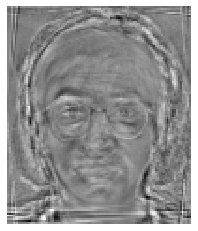

In [48]:
for i in range(U.shape[1]):
    plt.axis('off')
    f1 = plt.imshow(U[:, i].reshape(116, 98), interpolation = 'nearest')
#     fn = 'eigenface' + str(i).zfill(2) + '.png'
#     plt.savefig(fn, bbox_inches = 'tight', pad_inches = 0)
    plt.show()

#### Nhắc lại các bước tính PCA
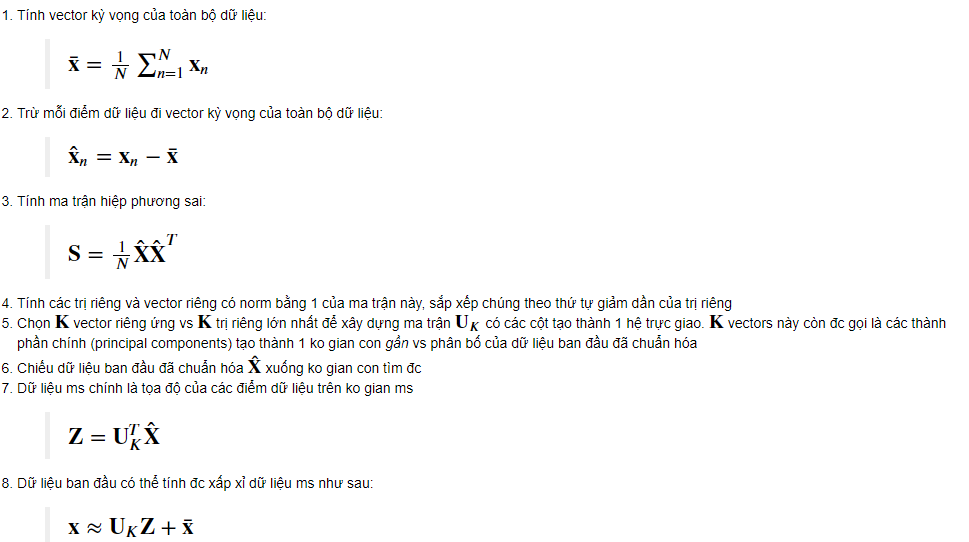

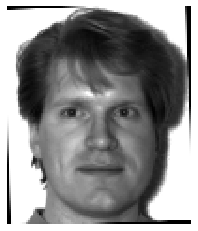

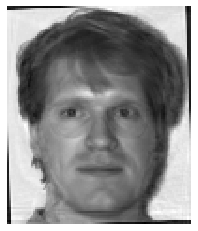

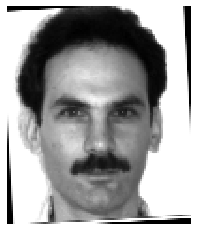

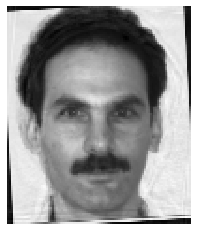

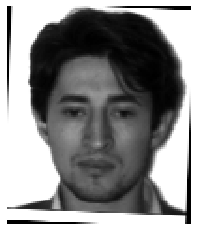

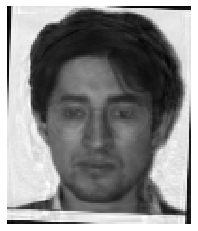

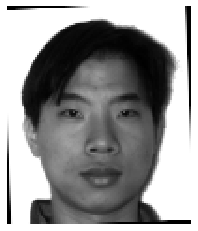

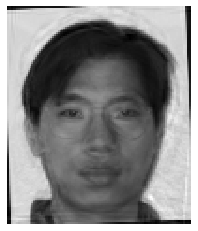

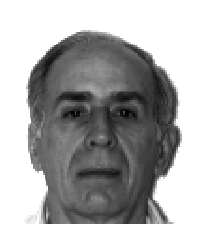

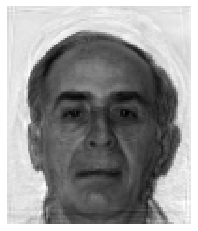

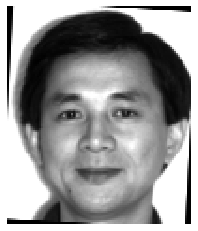

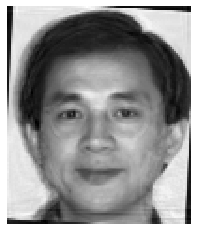

In [55]:
for person_id in range(1, 7):
    for state in ['centerlight']:
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        im = plt.imread(fn)
        plt.axis('off')
        f1 = plt.imshow(im, interpolation = 'nearest')
        plt.gray()
        plt.show()
        
        # reshape and subtract mean, don't forget 
        x = im.reshape(D, 1) - pca.mean_.reshape(D, 1)
        # encode
        z = U.T.dot(x)
        # decode
        x_tilde = U.dot(z) + pca.mean_.reshape(D, 1)

        # reshape to orginal dim
        im_tilde = x_tilde.reshape(116, 98)
        plt.axis('off')
        f1 = plt.imshow(im_tilde, interpolation = 'nearest')
        plt.gray()
        plt.show()

### Unsupervised Abnormal Detection
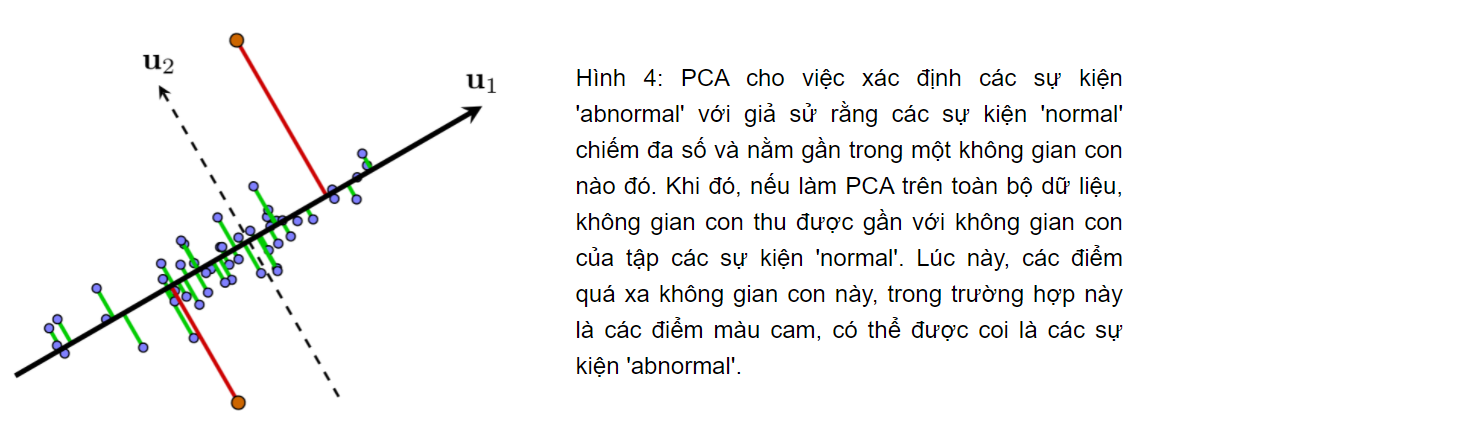